<a href="https://colab.research.google.com/github/ansariwaleed/python_projects/blob/main/implementing__neural_network_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What is Neural Network? - mathematical function that maps a given input to a desired outut.


> Neural Network consist of the following componenets
1.   An input layer,x
2.   An arbitary amount of hidden layers
3.   An output layer, y cap
4. A set of weights and biases between each layers, W and b
5. A choice of activation functions for each hidden layer, σ. Here we will use digmoid activation function.
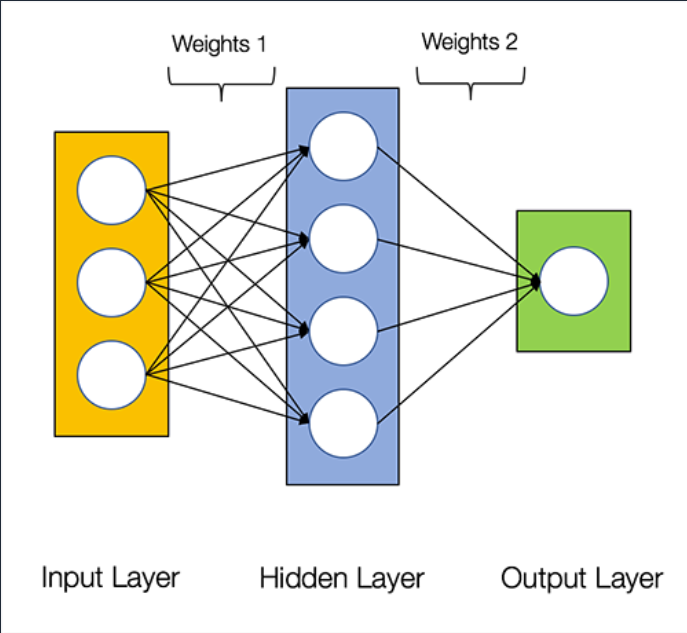



In [2]:
#importing imp libraries
import numpy as np

In [14]:
#create sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    return 1 / (1 + np.exp(-x))
'''
   1. using sigmoid the fucntion can capture non-linear funtions also.
   2. also sqaush output in 0 and 1
   3. it has smooth gradient so it helps in backpropagation.
   '''

'\n   1. using sigmoid the fucntion can capture non-linear funtions also.\n   2. also sqaush output in 0 and 1\n   3. it has smooth gradient so it helps in backpropagation.\n   '

In [17]:
#basic neral network
class NeuralNetwork:
  def __init__(self,x,y):
    self.input
    self.weights1 = np.random.rand(self.input.shape[1],4)
    self.weights2 = np.random.rand(4,1)
    self.y       = y
    self.output  = np.zeros(y.shape)

This code sets up a basic neural network with an input layer, one hidden layer with 4 neurons, and an ouput layer with 1 neuron. - The weigths are initialized randmly , and the output is initially set to zero.

The output of a simple 2 - layer Neural Network is :
> 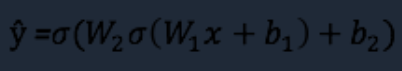
- the weights and biases are the only variables that affects the output.
- right values of for the weigths and biases determine the stregth of the predictions. - the process is known as Training the neural network.

> Each iteration of the training process consist of the following steps.
- Calculating the predicted ouput, known as feedforward
- updating the weigth and biases, known as backpropgation.

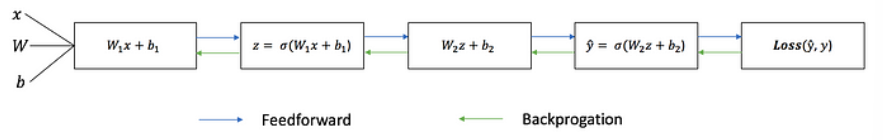

> Feedforward - as we have seen feedforwad is jsut a simple calculus for a basic
2- layer neural network.
- lets add one.


In [7]:
#note for simplicity we have assumed the biases to be 0.
class NeuralNetwork:
  def __init__(self,x,y):
    self.input     = x
    self.weights1  = np.random.rand(self.input.shape[1],4)
    self.weightes2 = np.randm.rand9(4,1)
    self.y         = y
    self.ouput     = np.zeros(self.y.shape)

  def feedforward(self):
    self.layer1 = sigmoid(np.dot(self.input, self.weights1))
    self.output = sigmoid(np.dot(self.layer1, self.weights2))


this code performs the feedforward pass of a simple neural network with one hidden layer. It processes the input through the network and produces the final output using weighted sums and the sigmoid activation function at each layer

Loss fucntion - there are many available loss functions, nature of our problem should dictate our loss function.
- here we will use simple sum - of - sqaure error.
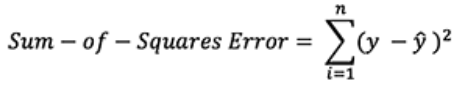

- it is simply the sum of the diffrenece between each pedicted value vs actual value.- squared for absolute value measurment.

- our goal in training is to find the best set of weights and baises that maximizes the loss function.

Backpropogation - we've measured the error of our prediction (loss), we need to find a way to propagate the error back, and to update our weights and biases.

In order to know the appropriate amount to adjust the weights and biases by, we need to know the derivative of the loss function with respect to the weights and biases.
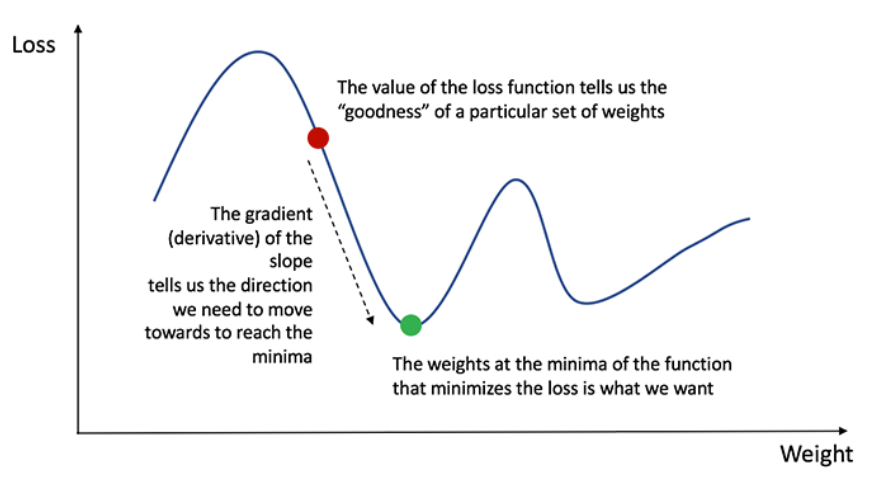

> If we have the derivative , we can simply update the weight and biases by increasing/reducing with it - This is known as gradient descent.

> we can't directly calculate the derivative of the loss function with respect to the weights and biases because the eqaution of the loss fucntion does not contain the weights and baises. Therefore we need chain rule.

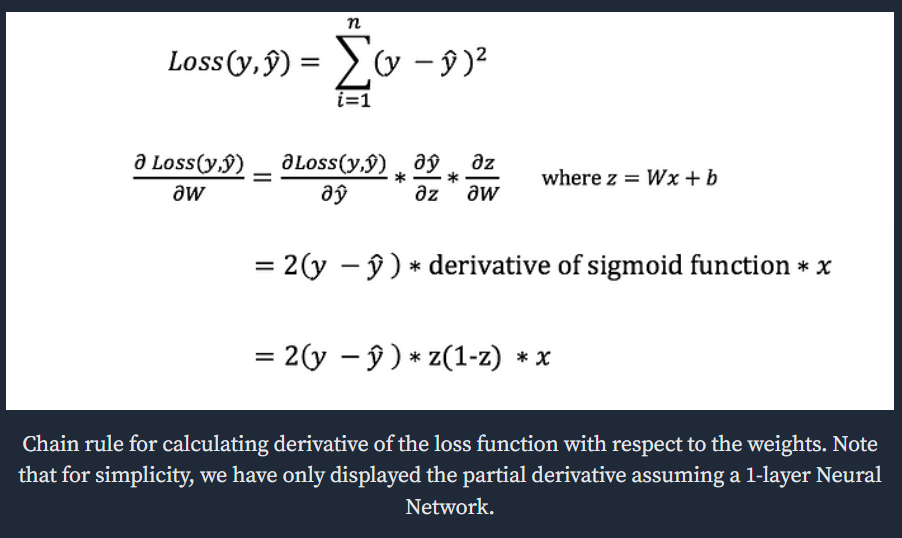


In [21]:

class NeuralNetwork:
    def __init__(self, x, y):
        self.input      = x
        self.weights1   = np.random.rand(self.input.shape[1],4)
        self.weights2   = np.random.rand(4,1)
        self.y          = y
        self.output     = np.zeros(self.y.shape)

    def feedforward(self):
        self.layer1 = sigmoid(np.dot(self.input, self.weights1))
        self.output = sigmoid(np.dot(self.layer1, self.weights2))

    def backprop(self):
      # app;ication of the chian rule to find derivative of the loss funtion with respect to weights2 and weights1
      d_weights2 = np.dot(self.layer1.T, (2*(self.y - self.output) * sigmoid_derivative(self.output)))
      d_weights1 = np.dot(self.input.T,  (np.dot(2*(self.y - self.output) * sigmoid_derivative(self.output), self.weights2.T) * sigmoid_derivative(self.layer1)))

      #update the weights with the derivative (slope) of the loss function
      self.weights1 += d_weights1
      self.weights2 += d_weights2


In [22]:
# Example data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Initialize and train the neural network
nn = NeuralNetwork(X, y)

# Train the network for a set number of iterations
for epoch in range(10000):
    nn.feedforward()
    nn.backprop()

print(nn.output)

[[0.49994996]
 [0.49984407]
 [0.50027065]
 [0.50015494]]


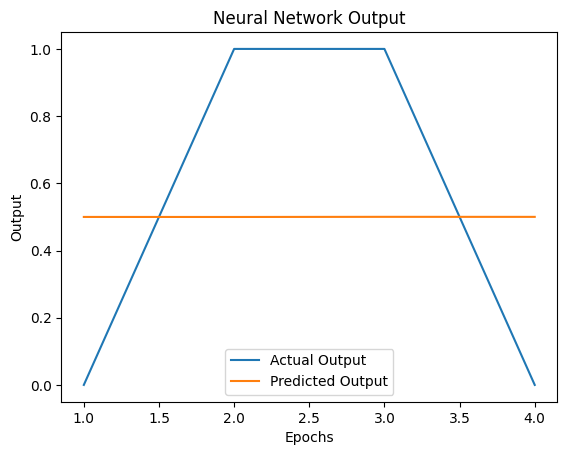

In [23]:
import matplotlib.pyplot as plt

predicted_output = nn.output.flatten()
actual_output = y.flatten()

epochs = range(1, len(predicted_output) + 1)

plt.plot(epochs, actual_output, label='Actual Output')
plt.plot(epochs, predicted_output, label='Predicted Output')
plt.xlabel('Epochs')
plt.ylabel('Output')
plt.title('Neural Network Output')
plt.legend()
plt.show()